In [1]:
import pandas as pd
df=pd.read_csv('coffe_sales.csv',sep=',')
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [2]:
df.isna().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [3]:
import matplotlib.pyplot as plt
df['coffee_name'].unique()

<StringArray>
[              'Latte',       'Hot Chocolate',           'Americano',
 'Americano with Milk',               'Cocoa',             'Cortado',
            'Espresso',          'Cappuccino']
Length: 8, dtype: str

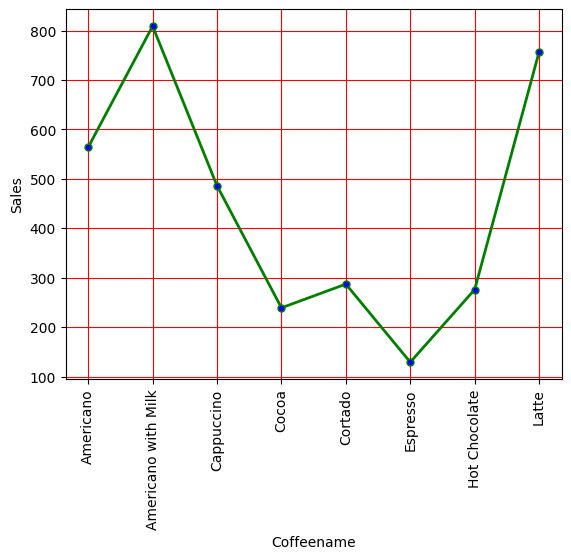

In [4]:
Count=df.groupby('coffee_name').size()
plt.plot(Count,c='g',marker='o',markerfacecolor='b',markersize=5,linewidth=2)
plt.xlabel('Coffeename')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.grid(c='r')
plt.show()

Conclusion :- The Americano with Milk has more demand while the Espresso has the least.So,making more 'Americano with Milk' coffee will become benefit to increase the sales amount.

In [5]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

Month = df.groupby("Month_name").size()
Month = Month.reindex(month_order)
Month


Month_name
January        NaN
February       NaN
March          NaN
April          NaN
May          241.0
June           NaN
July           NaN
August         NaN
September      NaN
October        NaN
November       NaN
December       NaN
dtype: float64

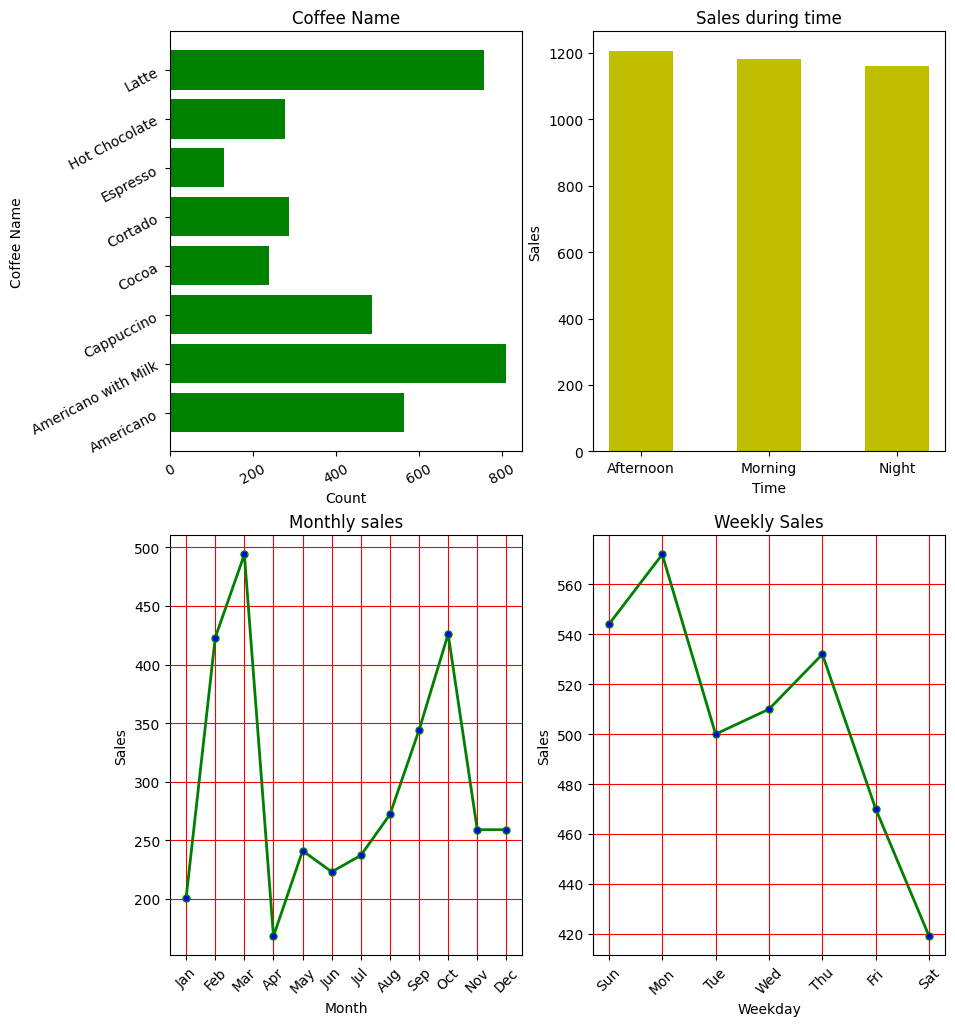

In [9]:
fig, axs = plt.subplots(2,2,figsize=(10,12))

Coffee=df.groupby('coffee_name').size()
Time=df.groupby('Time_of_Day').size()
Month=df.groupby('Monthsort').size().sort_index()
Weekday=df.groupby('Weekdaysort').size().sort_index()


axs[0,0].barh(Coffee.index,Coffee.values,color='g')
axs[0,0].set_xlabel('Count')
axs[0,0].set_ylabel('Coffee Name')
axs[0,0].set_title('Coffee Name')
axs[0,0].tick_params(rotation=28)
# axs[0,0].set_grid(c='r')
# axs[0,0].show()

axs[0,1].bar(Time.index,Time.values,color='y',linewidth=2,width=0.5)
axs[0,1].set_xlabel('Time')
axs[0,1].set_ylabel('Sales')
axs[0,1].set_title('Sales during time')
# axs[0,1].xticks(rotation=90)
# axs[0,1].grid(c='r')
# axs[0,1].show()

axs[1,0].plot(Month.index,Month.values,c='g',marker='o',markerfacecolor='b',markersize=5,linewidth=2)
axs[1,0].set_xlabel('Month')
axs[1,0].set_ylabel('Sales')
axs[1,0].set_title('Monthly sales')
axs[1,0].set_xticks(range(1,13))
axs[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
                          rotation=45)
axs[1,0].grid(c='r')
# axs[1,0].show()

axs[1,1].plot(Weekday,c='g',marker='o',markerfacecolor='b',markersize=5,linewidth=2)
axs[1,1].set_xlabel('Weekday')
axs[1,1].set_ylabel('Sales')
axs[1,1].set_title('Weekly Sales')
axs[1,1].set_xticks(range(1,8))
axs[1,1].set_xticklabels(['Sun','Mon','Tue','Wed','Thu','Fri','Sat'],rotation=45)
axs[1,1].grid(c='r')
# axs[1,1].show()

Conclusion :- From the given graphs, it's showing that coffee 'Americano with Milk' & 'Latte' has the more number of sales comparing with other. Sales are highest during the afternoon and stronger in the early part of the week. Sales are higher during March, and suddenly it drops too much in April.There are noticeable drops in certain months and during night time, indicating inconsistent demand.

To increase sales, the company should:
* Focus more on promoting its best-selling milk-based drinks.
* Introduce offers during low-sales periods like night-time.
* Provide discount during weekends.
